<a href="https://colab.research.google.com/github/mariasvynchuk/e-comerce-sql-analysis/blob/main/Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
from statsmodels.api import stats
from IPython.display import display

# Імпорт бд

In [ ]:
auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")
query = """
WITH
  session_info AS (
    SELECT
      s.date,
      s.ga_session_id,
      sp.country,
      sp.device,
      sp.continent,
      sp.channel,
      ab.test,
      ab.test_group
    FROM DA.ab_test ab
    JOIN DA.session s
      ON ab.ga_session_id = s.ga_session_id
    JOIN DA.session_params sp
      ON ab.ga_session_id = sp.ga_session_id
  ),
  sessions_with_orders AS (
    SELECT
      session_info.date,
      session_info.country,
      session_info.device,
      session_info.continent,
      session_info.channel,
      session_info.test,
      session_info.test_group,
      COUNT(DISTINCT o.ga_session_id) AS sessions_with_orders
    FROM DA.order o
    JOIN session_info
      ON o.ga_session_id = session_info.ga_session_id
    GROUP BY
      session_info.date,
      session_info.country,
      session_info.device,
      session_info.continent,
      session_info.channel,
      session_info.test,
      session_info.test_group
  ),
  events AS (
    SELECT
      session_info.date,
      session_info.country,
      session_info.device,
      session_info.continent,
      session_info.channel,
      session_info.test,
      session_info.test_group,
      ep.event_name,
      COUNT(ep.ga_session_id) AS event_cnt
    FROM DA.event_params ep
    JOIN session_info
      ON ep.ga_session_id = session_info.ga_session_id
    GROUP BY
      session_info.date,
      session_info.country,
      session_info.device,
      session_info.continent,
      session_info.channel,
      session_info.test,
      session_info.test_group,
      ep.event_name
  ),
  sessions AS (
    SELECT
      session_info.date,
      session_info.country,
      session_info.device,
      session_info.continent,
      session_info.channel,
      session_info.test,
      session_info.test_group,
      COUNT(DISTINCT session_info.ga_session_id) AS sessions_cnt
    FROM DA.event_params ep
    JOIN session_info
      ON ep.ga_session_id = session_info.ga_session_id
    GROUP BY
      session_info.date,
      session_info.country,
      session_info.device,
      session_info.continent,
      session_info.channel,
      session_info.test,
      session_info.test_group
  ),
  new_accounts AS (
    SELECT
      session_info.date,
      session_info.country,
      session_info.device,
      session_info.continent,
      session_info.channel,
      session_info.test,
      session_info.test_group,
      COUNT(DISTINCT acs.ga_session_id) AS new_accounts_cnt
    FROM DA.account_session acs
    JOIN session_info
      ON acs.ga_session_id = session_info.ga_session_id
    GROUP BY
      session_info.date,
      session_info.country,
      session_info.device,
      session_info.continent,
      session_info.channel,
      session_info.test,
      session_info.test_group
  )
SELECT
  sessions_with_orders.date,
  sessions_with_orders.country,
  sessions_with_orders.device,
  sessions_with_orders.continent,
  sessions_with_orders.channel,
  sessions_with_orders.test,
  sessions_with_orders.test_group,
  "sessions_with_orders" AS event_name,
  sessions_with_orders.sessions_with_orders AS value
FROM sessions_with_orders
UNION ALL
SELECT
  events.date,
  events.country,
  events.device,
  events.continent,
  events.channel,
  events.test,
  events.test_group,
  events.event_name,
  events.event_cnt AS value
FROM events
UNION ALL
SELECT
  sessions.date,
  sessions.country,
  sessions.device,
  sessions.continent,
  sessions.channel,
  sessions.test,
  sessions.test_group,
  "session" AS event_name,
  sessions.sessions_cnt AS value
FROM sessions
UNION ALL
SELECT
  new_accounts.date,
  new_accounts.country,
  new_accounts.device,
  new_accounts.continent,
  new_accounts.channel,
  new_accounts.test,
  new_accounts.test_group,
  "new_account" AS event_name,
  new_accounts.new_accounts_cnt AS value
FROM new_accounts
"""
query_job = client.query(query)
results = query_job.result()
df = results.to_dataframe()
df.head()

,date,country,device,continent,channel,test,test_group,event_name,value
0,2020-11-01,Jamaica,desktop,Americas,Organic Search,2,1,sessions_with_orders,1
1,2020-11-02,North Macedonia,desktop,Europe,Organic Search,2,2,sessions_with_orders,1
2,2020-11-03,Kenya,desktop,Africa,Undefined,2,2,sessions_with_orders,1
3,2020-11-04,Ecuador,desktop,Americas,Organic Search,2,1,sessions_with_orders,1
4,2020-11-05,Bulgaria,desktop,Europe,Direct,2,1,sessions_with_orders,1


#Обчислення основних метрик

In [ ]:
#calculate conversions, absolute/relative lift, and statistical significance between two groups
def ab_test(numerator :str, denominator:str, group_a: pd.DataFrame, group_b: pd.DataFrame):
  """
    Calculates conversion rates and statistical significance for two groups.

    Args:
        numerator (str): Name of the numerator of metric.
        denominator (str): Name of the denominator of metric.
        group_a (pd.DataFrame): Sample group A data.
        group_b (pd.DataFrame): Sample group B data.

    Returns:
        dict: Dictionary containing conversions, totals, conversion rates, metric changes, z-stat, p-value, and significance.
    """
  result ={}
  conversions_a = group_a[group_a["event_name"] == numerator]["value"].sum()
  total_a = group_a[group_a["event_name"] == denominator]["value"].sum()

  conversions_b = group_b[group_b["event_name"] == numerator]["value"].sum()
  total_b = group_b[group_b["event_name"] == denominator]["value"].sum()

  if total_a == 0 or total_b == 0:
    result.update({"res":None})
  else:
    conversion_a = conversions_a/total_a
    conversion_b = conversions_b/total_b
    metric_change = conversion_b-conversion_a
    relative_change = (conversion_b / conversion_a - 1)*100 if conversion_a != 0 else None
    z_stat, p_value = stats.proportions_ztest([conversions_a,conversions_b],[total_a,total_b])
    if p_value<0.05:
      significant = True
    else:
      significant = False

    result.update({"conversions_a": conversions_a, "total_a": total_a,
                   "conversions_b": conversions_b, "total_b": total_b,
                   "conversion_a": conversion_a, "conversion_b": conversion_b,
                   "metric_change": metric_change, "relative_change":relative_change,
                   "z_stat": z_stat, "p_value": p_value,
                   "significant": significant})

  return result

In [ ]:
#create sample groups A and B for a given test, metric, and optional segment/dimensios
def sample(numerator:str, denominator:str, test:int, column = None, item = None):
  """
    Returns group A and B samples for a given test and optional segment/dimension.

    Args:
        numerator (str): Name of the numerator of metric.
        denominator (str): Name of the denominator of metric.
        test (int): Test number.
        column (str, optional): Column name for segmentation.
        item (str, optional): Specific segment value.

    Returns:
        tuple: (group_a, group_b, result (dict) )
  """
  result ={"test": test, "metric": f"{numerator} / {denominator}",
            "numerator": numerator, "denominator": denominator}
  if column == None:
    group_a =  df[(df["test"]==test) & (df["test_group"] == 1)]
    group_b =  df[(df["test"]==test) & (df["test_group"] == 2)]
  else:
    group_a =  df[(df["test"]==test) & (df["test_group"] == 1) & (df[column]==item)]
    group_b =  df[(df["test"]==test) & (df["test_group"] == 2) & (df[column]==item)]
    result["dimension"] = column
    result["segment"] = item

  return group_a, group_b, result

In [ ]:
#calculating the results of ab test for all main metrics
metrics = ["add_payment_info / session","add_shipping_info / session", "begin_checkout / session", "new_account / session"]

all_data = []
for metric in metrics:
  numerator, denominator = [part.strip() for part in metric.split('/')]
  for test in range(1,5):
     data={} #results for one test
     group_a, group_b, result = sample(numerator, denominator, test) #sampling
     data.update(result)
     result = ab_test(numerator, denominator, group_a, group_b)#counting
     data.update(result)
     all_data.append(data)#append the resulting list with results of this test

all_data = pd.DataFrame(all_data)
display(all_data)

,test,metric,numerator,denominator,conversions_a,total_a,conversions_b,total_b,conversion_a,conversion_b,metric_change,relative_change,z_stat,p_value,significant
0,1,add_payment_info / session,add_payment_info,session,1988,45362,2229,45193,0.043825,0.049322,0.005497,12.542021,-3.924884,0.000087,True
1,2,add_payment_info / session,add_payment_info,session,2344,50637,2409,50244,0.046290,0.047946,0.001656,3.576911,-1.240994,0.214608,False
2,3,add_payment_info / session,add_payment_info,session,3623,70047,3697,70439,0.051722,0.052485,0.000763,1.474630,-0.643172,0.520112,False
3,4,add_payment_info / session,add_payment_info,session,3731,105079,3601,105141,0.035507,0.034249,-0.001257,-3.541234,1.571106,0.116158,False
4,1,add_shipping_info / session,add_shipping_info,session,3034,45362,3221,45193,0.066884,0.071272,0.004388,6.560481,-2.603571,0.009226,True
5,2,add_shipping_info / session,add_shipping_info,session,3480,50637,3510,50244,0.068724,0.069859,0.001135,1.650995,-0.709557,0.477979,False
6,3,add_shipping_info / session,add_shipping_info,session,5298,70047,5188,70439,0.075635,0.073652,-0.001983,-2.621211,1.413727,0.157442,False
7,4,add_shipping_info / session,add_shipping_info,session,5128,105079,4956,105141,0.048801,0.047137,-0.001665,-3.411125,1.785795,0.074132,False
8,1,begin_checkout / session,begin_checkout,session,3784,45362,4021,45193,0.083418,0.088974,0.005556,6.660587,-2.978783,0.002894,True
9,2,begin_checkout / session,begin_checkout,session,4262,50637,4313,50244,0.084168,0.085841,0.001673,1.988164,-0.952898,0.340642,False


In [ ]:
all_data.to_csv('ab_test_results.csv', index=False)

## В розрізах

In [ ]:
#count test results for named dimesion and segment of all data
def segment_count(dimension, segment):
  """
    Returns all the results of ab test calculations for named dimension and a particular segment.

    Args:
        dimension(str): name of the dimension.
        segment(str): name of the segment.

    Returns:
        dict: Dictionary containing conversions, totals, conversion rates, metric changes, z-stat, p-value, and significance.
  """
  res=[]
  for metric in metrics:
     numerator, denominator = [part.strip() for part in metric.split('/')]
     for test in range(1,5):
        data={}
        group_a, group_b, result = sample(numerator, denominator, test, column = dimension, item = segment)
        data.update(result)
        result = ab_test(numerator, denominator, group_a, group_b)
        data.update(result)
        res.append(data)
  return res

In [ ]:
segments_data=[] #tests results across all segments

#by devices
for item in pd.unique(df["device"]):
  data = segment_count("device",item)
  segments_data = segments_data + data

#by channels
for item in pd.unique(df["channel"]):
  data = segment_count("channel",item)
  segments_data = segments_data + data

#by continents
for item in pd.unique(df["continent"]):
  data = segment_count("continent",item)
  segments_data = segments_data + data

segments_data = pd.DataFrame(segments_data)
display(segments_data)

,test,metric,numerator,denominator,dimension,segment,conversions_a,total_a,conversions_b,total_b,conversion_a,conversion_b,metric_change,relative_change,z_stat,p_value,significant
0,1,add_payment_info / session,add_payment_info,session,device,mobile,810,17896,942,17767,0.045262,0.053020,0.007758,17.140683,-3.389330,0.000701,True
1,2,add_payment_info / session,add_payment_info,session,device,mobile,978,20017,961,19756,0.048858,0.048643,-0.000215,-0.440088,0.099562,0.920692,False
2,3,add_payment_info / session,add_payment_info,session,device,mobile,1463,27404,1463,27423,0.053386,0.053349,-0.000037,-0.069285,0.019267,0.984628,False
3,4,add_payment_info / session,add_payment_info,session,device,mobile,1413,41216,1501,41345,0.034283,0.036304,0.002021,5.896444,-1.573870,0.115517,False
4,1,add_shipping_info / session,add_shipping_info,session,device,mobile,1257,17896,1256,17767,0.070239,0.070693,0.000454,0.645933,-0.167387,0.867065,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,4,begin_checkout / session,begin_checkout,session,continent,(not set),59,234,35,262,0.252137,0.133588,-0.118549,-47.017725,3.362949,0.000771,True
220,1,new_account / session,new_account,session,continent,(not set),7,97,11,100,0.072165,0.110000,0.037835,52.428571,-0.921405,0.356839,False
221,2,new_account / session,new_account,session,continent,(not set),8,89,11,130,0.089888,0.084615,-0.005272,-5.865385,0.136142,0.891709,False
222,3,new_account / session,new_account,session,continent,(not set),12,175,9,152,0.068571,0.059211,-0.009361,-13.651316,0.344399,0.730546,False


In [ ]:
significant_data = segments_data[segments_data["significant"] == True]
display(significant_data.pivot_table(
    index=["dimension", "segment"],
    columns="metric",
    values="metric_change"))

metric                    add_payment_info / session  \
dimension segment                                      
channel   Direct                            0.013136   
          Organic Search                   -0.006827   
          Paid Search                       0.005621   
          Social Search                    -0.000790   
          Undefined                         0.027785   
continent (not set)                        -0.063483   
          Africa                           -0.034088   
          Americas                          0.004239   
          Asia                                   NaN   
          Europe                            0.000948   
          Oceania                          -0.032946   
device    desktop                           0.001096   
          mobile                            0.007758   
          tablet                           -0.019710   

metric                    add_shipping_info / session  \
dimension segment                                       
channel   Direct                             0.006997   
          Organic Search                    -0.004565   
          Paid Search                        0.006292   
          Social Search                     -0.007945   
          Undefined                          0.029131   
continent (not set)                          0.013407   
          Africa                            -0.045482   
          Americas                                NaN   
          Asia                                    NaN   
          Europe                             0.001504   
          Oceania                            0.008803   
device    desktop                            0.002357   
          mobile                                  NaN   
          tablet                            -0.015255   

metric                    begin_checkout / session  new_account / session  
dimension segment                                                          
channel   Direct                          0.011331              -0.005850  
          Organic Search                 -0.007929              -0.004423  
          Paid Search                     0.002251                    NaN  
          Social Search                  -0.017026                    NaN  
          Undefined                       0.040463              -0.017517  
continent (not set)                       0.030107                    NaN  
          Africa                         -0.021056                    NaN  
          Americas                       -0.006709              -0.006460  
          Asia                            0.007844              -0.005854  
          Europe                         -0.001973                    NaN  
          Oceania                         0.010172                    NaN  
device    desktop                         0.003657              -0.003334  
          mobile                         -0.000710                    NaN  
          tablet                         -0.030214                    NaN

# Візуалізації

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

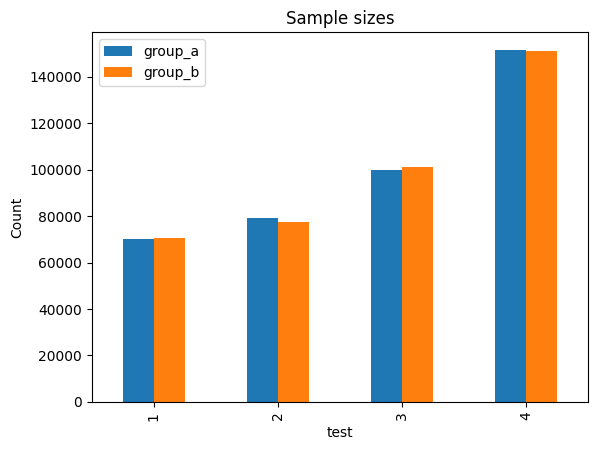

In [ ]:
#sample size distribution
metrics = ["add_payment_info / session","add_shipping_info / session", "begin_checkout / session", "new_account / session"]

#creating df with col: test, lenght of group a, length of group b
sample_sizes = []
for test in range(1,5):
  group_a, group_b, result = sample(_, _, test)
  sample_sizes.append([test, len(group_a), len(group_b)])
sample_sizes = pd.DataFrame(sample_sizes, columns = ["test", "group_a", "group_b"])
sample_sizes = sample_sizes.set_index("test")[["group_a", "group_b"]]

#plotting
sample_sizes.plot(kind="bar")
plt.ylabel("Count")
plt.title(f"Sample sizes")
plt.show()

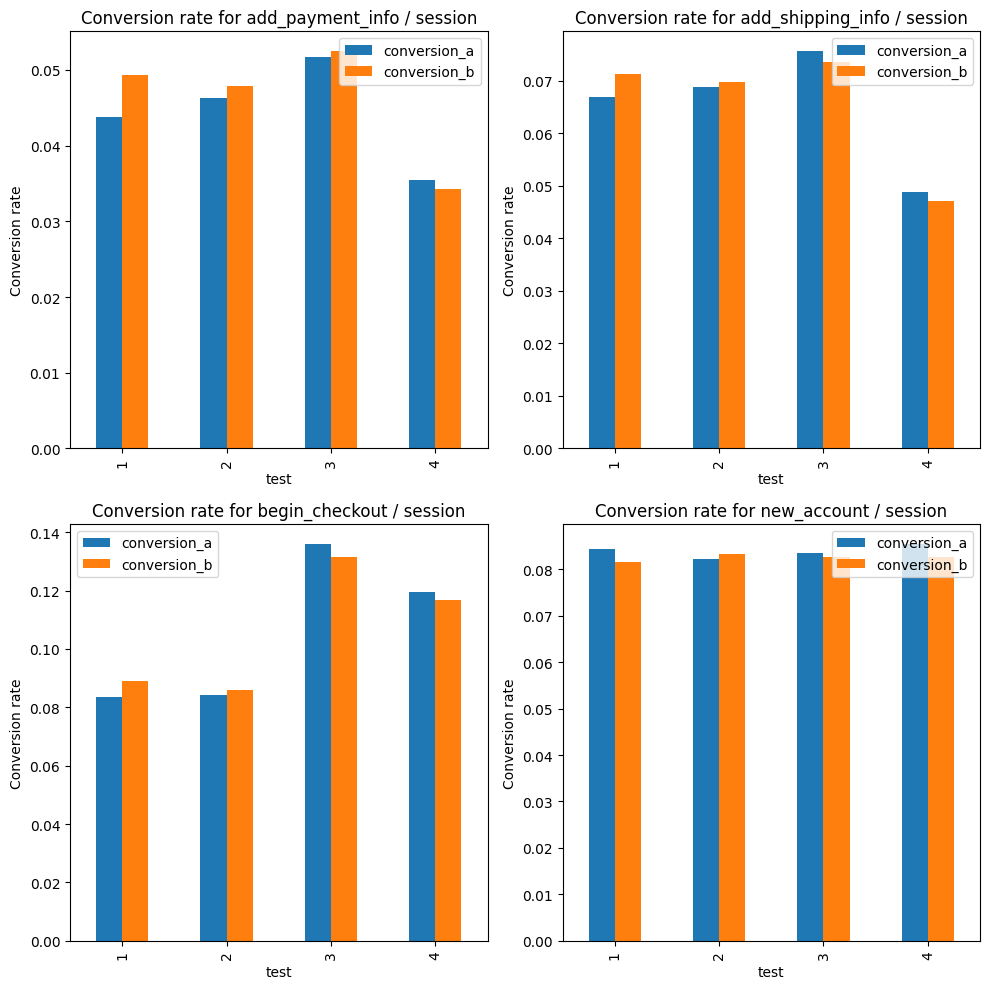

In [ ]:
#conversion rates
fig, axes = plt.subplots(2,2, figsize=(10,10))
axes = axes.flatten()

i=0
for metric in pd.unique(all_data["metric"]):
    #temporary dataframe for one plot
    temp_df = all_data[all_data["metric"] == metric]
    temp_df = temp_df.set_index("test")[["conversion_a", "conversion_b"]]

    #plotting
    temp_df.plot(kind="bar", ax = axes[i])
    axes[i].set_title(f"Conversion rate for {metric}")
    axes[i].set_ylabel("Conversion rate")
    i+=1

plt.tight_layout()
plt.show()

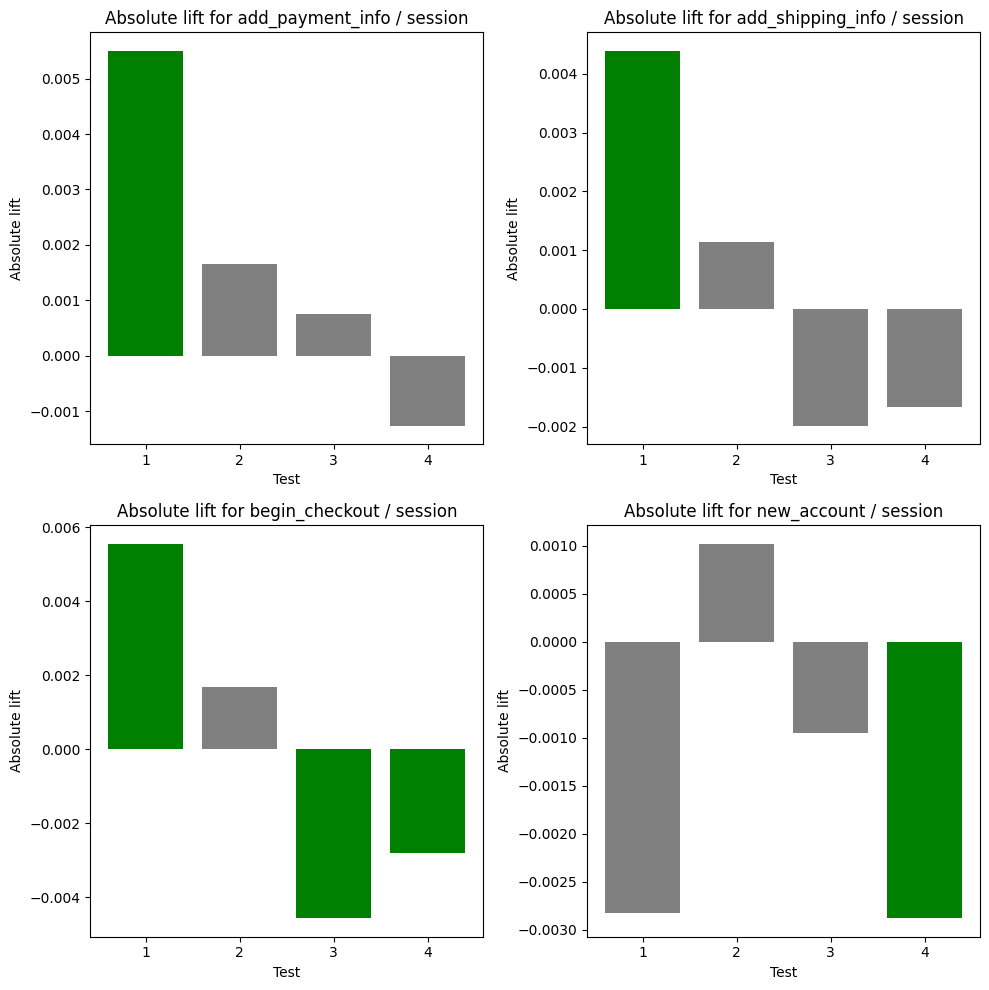

In [ ]:
#absolute lift: green bars indicate statistically significant results
fig, axes = plt.subplots(2,2, figsize=(10,10))
axes = axes.flatten()

i=0
for metric in pd.unique(all_data["metric"]):
    #temporary data frame with filtered data
    temp_df = all_data[all_data["metric"] == metric]
    colors = temp_df["significant"].map({True: "green", False: "gray"}) #significant results in green
    x = temp_df["test"].astype(str) #to categorical test name value

    axes[i].bar(x,temp_df["metric_change"], color=colors)
    axes[i].set_title(f"Absolute lift for {metric}")
    axes[i].set_ylabel("Absolute lift")
    axes[i].set_xlabel("Test")
    i+=1

plt.tight_layout()
plt.show()

test,1,3,4
metric,,,
add_payment_info / session,12.542021,Not Significant,Not Significant
add_shipping_info / session,6.560481,Not Significant,Not Significant
begin_checkout / session,6.660587,-3.352445,-2.351523
new_account / session,Not Significant,Not Significant,-3.362896


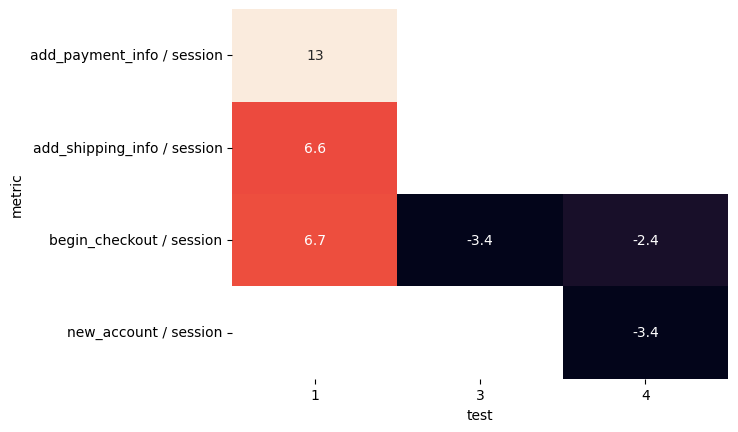

In [ ]:
#relative change heatmap (significant only)
plot_df = all_data[all_data["significant"]==True].pivot(index="metric",
                                                        columns="test",
                                                        values="relative_change"
                                                        ) #temp df for plotting
display(plot_df.fillna("Not Significant"))

sns.heatmap(plot_df, annot=True, cbar=False)
plt.show()


# CSV файл з результатами

https://drive.google.com/file/d/1R1rhP2SIYg4ZULUw-F9G6O4QHJP6DK6s/view?usp=sharing

# Tableau Дашборд

Огляд результатів A/B-тестування: обсяги вибірки, розподіл подій, конверсії та статистична значущість за тестовими групами.

https://public.tableau.com/app/profile/mariia.svynchuk/viz/ABtest_17694514620040/ABtest